Processing: Smoothing
Processing: Strong_Filtering
Processing: Echo


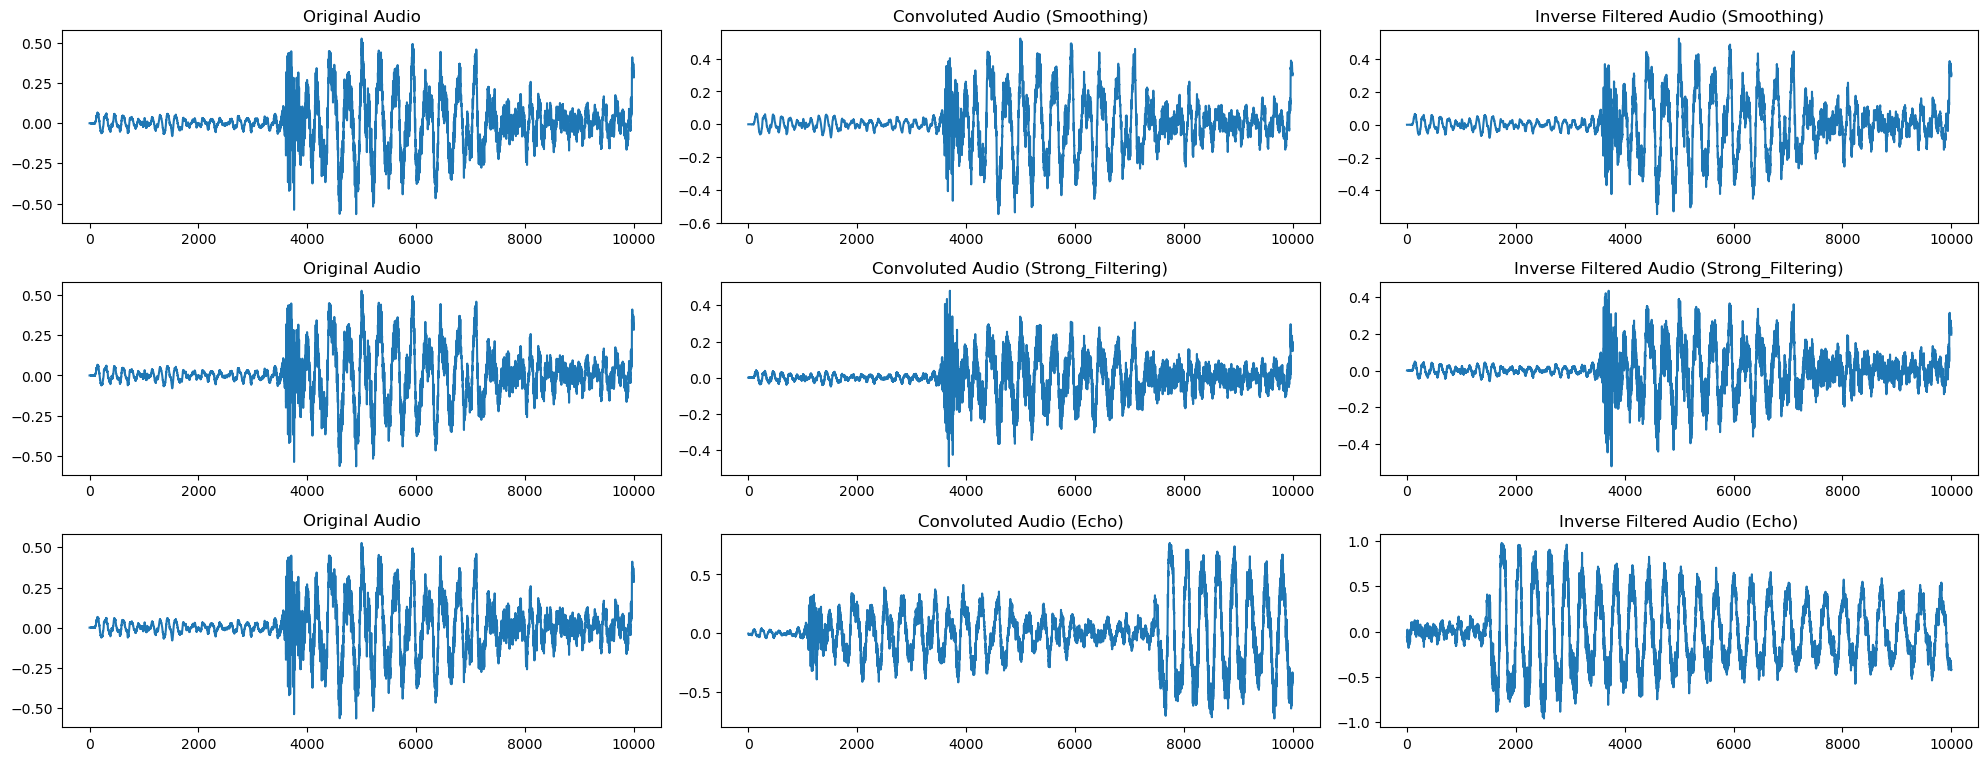

In [5]:
from pydub import AudioSegment
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve

audio = AudioSegment.from_mp3("audio.mp3")

audio = audio.set_channels(1)
samples = np.array(audio.get_array_of_samples()).astype(np.float32)

samples_norm = samples / np.max(np.abs(samples))

echo = np.zeros(5000, dtype=np.float32)
echo[0] = 1
echo[2000] = 0.4

inverse_echo = np.zeros(12000,dtype=np.float32)
inverse_echo[0] = 1
inverse_echo[2000] = -0.4
inverse_echo[4000] = 0.16
inverse_echo[6000] = -0.064
inverse_echo[8000] = 0.0256


impulse_responses = {
    "Smoothing": {
        "kernel": np.array([0.25, 0.5, 0.25], dtype=np.float32),
        "inverse": np.array([1, -0.5, 0.25], dtype=np.float32)
    },

    "Strong_Filtering": {
        "kernel": np.array([1, -0.5], dtype=np.float32),
        "inverse": np.array([1, 0.5], dtype=np.float32)
    },

    "Echo": {
        "kernel":echo,
        "inverse":inverse_echo
    },
}

start = 1000
end = 11000

plt.figure(figsize=(20,10))
plot_no = 1

# Perform convolution
for name, data in impulse_responses.items():

    kernel = data["kernel"]
    inverse_kernel = data["inverse"]
    
    print("Processing:", name)

    convoluted = convolve(samples, kernel, mode="same")
    # Normalize
    convoluted = convoluted / np.max(np.abs(convoluted))
    convoluted_int16 = (convoluted * 32767).astype(np.int16)

    # Create audio
    convoluted_audio = AudioSegment(
        convoluted_int16.tobytes(),
        frame_rate=audio.frame_rate,
        sample_width=2,
        channels=1
    )

    convoluted_audio.export(f"{name}.wav", format="wav")

    restored = convolve(convoluted,inverse_kernel,mode='same')
    #Normalize
    restored = restored / np.max(np.abs(restored))
    restored_int16 = (restored * 32767).astype(np.int16)

    restored_audio = AudioSegment(
        restored_int16.tobytes(),
        frame_rate=audio.frame_rate,
        sample_width=2,
        channels=1
    )

    restored_audio.export(f"{name}_inverse.wav",format="wav")

    plt.subplot(4,3,plot_no)
    plt.plot(samples_norm[start:end])
    plt.title("Original Audio")
    plot_no +=1

    plt.subplot(4,3,plot_no)
    plt.plot(convoluted[start:end])
    plt.title(f"Convoluted Audio ({name})")
    plot_no +=1

    plt.subplot(4,3,plot_no)
    plt.plot(restored[start:end])
    plt.title(f"Inverse Filtered Audio ({name})")
    plot_no +=1

plt.tight_layout()
plt.show()